### Data loading

In [1]:
import trimap
import pandas as pd

In [2]:
chronos = pd.read_csv("../data/CRISPR_gene_effect.csv",index_col=0)
chronos.columns = [c.split()[0].upper() + '_Chronos' for c in chronos.columns]
expression = pd.read_csv("../data/CCLE_expression.csv", index_col=0)
expression.columns = [c.split()[0].upper()+'_Expression' for c in expression.columns]
sample_info = pd.read_csv("../data/sample_info.csv", index_col=0)
ch_ex = chronos.merge(expression, right_index=True, left_index=True).dropna()

In [3]:
path = '../../../../../Boston/Webster/Gene selection/26Q1_result'
import pandas as pd
D = pd.read_csv(path + "/D.csv", index_col=0)
ch_ex_D = ch_ex.merge(D,left_index=True, right_index=True, how='left').copy()

In [4]:
id_to_name = {i:n for i, n in zip(sample_info.index, sample_info["stripped_cell_line_name"])}
name_to_id = {n:i for i, n in zip(sample_info.index, sample_info["stripped_cell_line_name"])}
name_to_lineage = {n:l for n, l in zip(sample_info["stripped_cell_line_name"], sample_info["lineage"])}
ch_ex_D.index = [id_to_name.get(n,n) for n in ch_ex_D.index]

In [5]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def calculate_network_smoothness(emb, values, k=15):
    valid_idx = ~np.isnan(values)
    emb_valid = emb[valid_idx]
    val_valid = values[valid_idx]
    
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(emb_valid)
    distances, indices = nbrs.kneighbors(emb_valid)
    
    distances = distances[:, 1:]
    indices = indices[:, 1:]
    
    dist_sq = distances**2
    mean_dist_sq = np.mean(dist_sq)
    
    weights = np.exp(-dist_sq / mean_dist_sq)
    
    probabilities = weights / np.sum(weights, axis=1, keepdims=True)
    
    local_smoothness = []
    
    for i in range(len(emb_valid)):
        current_val = val_valid[i]
        neighbor_vals = val_valid[indices[i]]
        diff_sq = (current_val - neighbor_vals)**2
        
        expected_diff_sq = np.sum(probabilities[i] * diff_sq)
        local_smoothness.append(expected_diff_sq)

    global_score = np.mean(local_smoothness)
    return global_score, np.array(local_smoothness)

### Webster score (Figs. 1b-d, S1f-h)

Text(0.5, 1.0, 'AXL Expression vs V13')

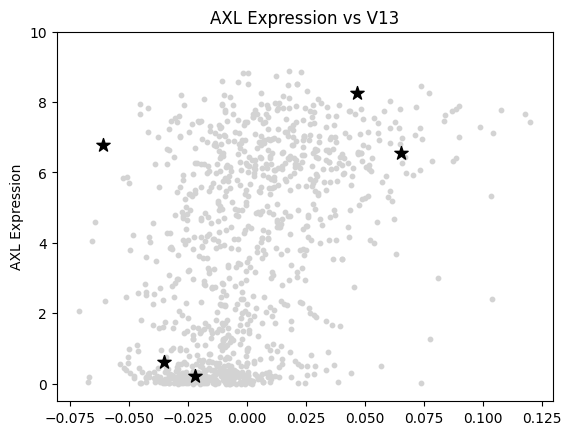

In [6]:
#Fig. 1c, d, S1f-h
import matplotlib.pyplot as plt
x_col = 'V13'
y_col = 'AXL_Expression'
cells = ['U2OS', 'RPE1SS48', 'PANC1', 'MCF7', 'K562']

plt.scatter(ch_ex_D[x_col], ch_ex_D[y_col], s=10, c='lightgray')
plt.scatter(ch_ex_D.loc[cells, x_col], ch_ex_D.loc[cells, y_col], s=100, c='black', marker='*')
plt.ylim((-0.5, 10))
plt.ylabel("AXL Expression")
plt.title("AXL Expression vs V13")


C:\Users\ki949\AppData\Local\Temp\ipykernel_38084\1534275516.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


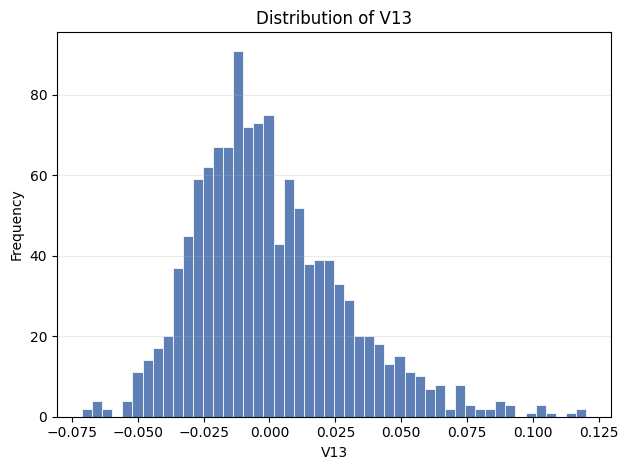

In [7]:
import matplotlib.pyplot as plt
import numpy as np

#Fig. 1b
x_data = D["V13"].dropna()
plt.hist(x_data, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.6, alpha=0.9)

plt.xlabel("V13")
plt.ylabel("Frequency")
plt.title("Distribution of V13")
plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Dimensionality reduction optimization (Figs. S2b, S2e)

In [8]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import networkx as nx
from sklearn.neighbors import kneighbors_graph

hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_exp=['YAP1','WWTR1','CCN1','AXL']

features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
scaled_data = StandardScaler().fit_transform(ch_ex[features]) 

In [9]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import rbf_kernel

dimensionality_reduction_methods = {
    "UMAP": umap.UMAP(random_state=0, n_neighbors=6, min_dist=0.08),
    "PCA": PCA(n_components=2),
    "t-SNE": TSNE(n_components=2, random_state=0),
    "Trimap": trimap.TRIMAP(n_dims=2, n_outliers=10, n_inliers=10)
}

embeddings = {}
graphs = {}
results = []
for method_name, reducer in dimensionality_reduction_methods.items():
    print(method_name)
    embedding = reducer.fit_transform(scaled_data)
    embeddings[method_name] = embedding

c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP


c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA
t-SNE
Trimap


In [10]:
#Global Score (GS)
#Fig. S2b
import numpy as np
X = scaled_data.T
y_pca = embeddings['PCA'].T
print(X.shape, y_pca.shape)
a = X@(y_pca.T)@np.linalg.inv(y_pca@y_pca.T)
e_pca = np.linalg.norm(X-a@y_pca,'fro')**2

def calc_e(X, y):
    a = X@(y.T)@np.linalg.inv(y@y.T)
    return np.linalg.norm(X-a@y,'fro')**2

e_pca = calc_e(X, y_pca)
y_umap = embeddings['UMAP'].T
e_umap = calc_e(X, y_umap)

y_tsne = embeddings['t-SNE'].T
e_tsne = calc_e(X, y_tsne)

y_trimap = embeddings['Trimap'].T
e_trimap = calc_e(X, y_trimap)

GS_pca = np.exp(-(e_pca-e_pca)/(e_pca))
GS_umap = np.exp(-(e_umap-e_pca)/(e_pca))
GS_tsne = np.exp(-(e_tsne-e_pca)/(e_pca))
GS_trimap = np.exp(-(e_trimap-e_pca)/(e_pca))

print("GS PCA:", GS_pca)
print("GS UMAP:", GS_umap)
print("GS t-SNE:", GS_tsne)
print("GS Trimap:", GS_trimap)

(15, 1001) (2, 1001)
GS PCA: 1.0
GS UMAP: 0.5467828442855684
GS t-SNE: 0.7792606337774236
GS Trimap: 0.8766608974505415


In [11]:
#Fig. S2e
from sklearn.preprocessing import StandardScaler
import numpy as np
import networkx as nx
from sklearn.neighbors import kneighbors_graph
wang = 'CCN1,CCN2,AMOTL2,ANKRD1,IGFBP3,F3,FJX1,NUAK2,LATS2,CRIM1,GADD45A,TGFB2,PTPN14,NT5E,FOXF2,AXL,DOCK5,ASAP1,RBMS3,MYOF,ARHGEF17,CCDC80'
wang = wang.split(',')

kanai='ABL2,ACAT2,ADAMTS6,ADRB2,ANKRD1,ANLN,ANXA2,AOX1,AXL,C12orf75,CCN1,CCN2,CEP55,CLDN1,CNN3,COL12A1,CPA4,CRIM1,CYTH3,DDAH1,DIAPH3,DKK1,DLC1,ELL2,EPAS1,EPB41L4B,EPG5,EPHA2,ESM1,ETS1,F3,FJX1,FOSL1,FSTL3,GADD45A,GADD45B,GFRA1,GNGT2,HBEGF,IL11,IL12A,IL7R,ITGB2,,KRT80,KRT81,LAMC2,LETM2,MB21D2,MFAP5,MPP4,MPP7,NAV3,NLRP3,NPPB,NUAK2,OXTR,PAWR,PCLO,PKP2,PRKAG2,RAB3B,RAPH1,RFTN1,RGS7,RNF144B,SFTA1P,SGMS2,SH2D5,SLC8A1,SMURF2,TEAD4,TGM2,TK1,TNFAIP3,TUBB6,VGLL3,WWC1,WWC2,ZNF367'
kanai = kanai.split(',')

kegg = 'PATJ,TPTEP2-CSNK1E,APC2,YAP1,YWHAQ,RASSF1,FZD10,FRMD6,WTIP,CSNK1D,CSNK1E,CCN2,CTNNA1,CTNNA2,CTNNB1,GDF7,AMOT,RASSF6,DLG1,AFP,DLG2,DLG3,DLG4,DVL1,DVL2,DVL3,FGF1,WWC1,FBXW11,CRB1,SCRIB,FZD2,WWTR1,LATS2,AMH,BBC3,GLI2,CRB2,CTNNA3,GSK3B,APC,BIRC2,BIRC3,BIRC5,ID1,ID2,BMP8A,ITGB2,AREG,GDF6,LLGL2,LLGL1,SMAD1,SMAD2,SMAD3,SMAD4,SMAD7,MYC,NF2,SERPINE1,PARD6A,LEF1,WNT16,WNT4,PPP1CA,PPP1CB,PPP1CC,PPP2CA,PPP2CB,PPP2R1A,PPP2R1B,PPP2R2A,PPP2R2B,PPP2R2C,MOB1A,PRKCI,PPP2R2D,PRKCZ,PARD3,CCND1,ACTB,SAV1,PALS1,BMP2,BMP4,BMP5,BMP6,BMP7,BMP8B,BMPR1A,BMPR1B,BMPR2,SNAI2,SOX2,STK3,TCF7,TCF7L2,TEAD1,TEAD4,TEAD3,TGFB1,TGFB2,TGFB3,TGFBR1,TGFBR2,ACTG1,TP53BP2,TP73,WNT1,WNT2,WNT3,WNT5A,WNT6,WNT7A,WNT7B,WNT8A,WNT8B,WNT10B,WNT11,WNT2B,WNT9A,WNT9B,YWHAB,YWHAE,YWHAG,YWHAH,YWHAZ,FZD5,FZD3,FRMD1,WNT10A,WNT5B,GDF5,AXIN1,AXIN2,FZD1,FZD4,FZD6,FZD7,FZD8,FZD9,TCF7L1,PARD6G,PARD6B,TEAD2,AJUBA,NKD1,NKD2,CCND2,BTRC,CCND3,WNT3A,LIMD1,LATS1,DLG5,MOB1B,CDH1'
kegg = kegg.split(',')

def trimap_smoothness(chr_genes, exp_genes, k=15):
    chr_genes = set([gene for gene in chr_genes if gene.upper() + '_Chronos' in ch_ex.columns])
    exp_genes = set([gene for gene in exp_genes if gene.upper() + '_Expression' in ch_ex.columns])
    features = [gene.upper() + '_Chronos' for gene in chr_genes] + [gene.upper() + '_Expression' for gene in exp_genes] 
    scaled_data = StandardScaler().fit_transform(ch_ex[features]) 
    reducer = trimap.TRIMAP(n_dims=2, n_outliers=10, n_inliers=10)
    embedding = reducer.fit_transform(scaled_data)
    global_score, local_smoothness = calculate_network_smoothness(embedding, ch_ex_D['V13'].values, k=k)  
    return global_score

print("Corr_MI:", trimap_smoothness(hippo_chr, hippo_exp, k=15))
print("KEGG_MI:", trimap_smoothness(kegg, hippo_exp, k=15))
print("Corr_Lit:", trimap_smoothness(hippo_chr, kanai + wang, k=15))
print("KEGG_Lit:", trimap_smoothness(kegg, kanai + wang, k=15))

Corr_MI: 0.0005085705650311106
KEGG_MI: 0.0008921064058506907
Corr_Lit: 0.0010499656659723393
KEGG_Lit: 0.0010961787344592406


### Mutual Information (Figs. S2c, f)

In [15]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression
genes = ['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL', 'LATS2', 'NRP1']
scaled_ch_ex = StandardScaler().fit_transform(ch_ex[[h.upper()+"_Chronos" for h in genes]])
s = scaled_ch_ex.mean(axis=1)
import tqdm
values = []
exp_col = [c for c in ch_ex.columns if 'Expression' in c]
for gene in tqdm.tqdm(exp_col):
    mi = mutual_info_regression(s.reshape(-1, 1), ch_ex[gene])
    values.append(mi[0])
values_df = pd.DataFrame({'gene':exp_col,'mi':values})

100%|██████████| 19221/19221 [02:13<00:00, 144.12it/s]


In [16]:
values_df['is_wang'] = values_df['gene'].str.replace('_Expression','').isin(wang)
values_df['is_kanai'] = values_df['gene'].str.replace('_Expression','').isin(kanai)
values_df.sort_values('mi', ascending=False).head(10)

,gene,mi,is_wang,is_kanai
8168,CCN1_Expression,0.216150,True,True
3200,CAV1_Expression,0.193568,False,False
130,TNFRSF12A_Expression,0.190657,False,False
11909,AXL_Expression,0.174990,True,True
12248,PXDC1_Expression,0.173227,False,False
13588,FOSL1_Expression,0.173053,False,True
1934,CCDC80_Expression,0.169984,True,False
11500,UBTD1_Expression,0.169213,False,False
108,ITGA3_Expression,0.167661,False,False
11116,GPX8_Expression,0.166383,False,False


### TriMAP visualization (Figs. 1e-k)

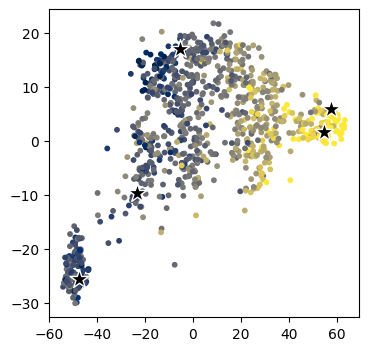

In [12]:
#Fig. 1e, h, j, k
import numpy as np
import pandas as pd

embedding = pd.read_csv("../trimap_hippo.csv",index_col=0).values
emb = embedding
plt.figure(figsize=(4, 4))
plt.scatter(emb[:, 0], emb[:, 1], c=ch_ex_D['V13'], s=10, cmap='cividis',vmin=-0.05, vmax=0.05,alpha=1)
cells = ['RPE1SS48','U2OS','K562','PANC1','MCF7']
cells_index = []
for cell in cells:
    cells_index.append(ch_ex_D.index.get_loc(cell))
plt.scatter(emb[cells_index, 0], emb[cells_index, 1], s=200, c='black', marker='*',edgecolors='white', linewidth=1)
plt.show()

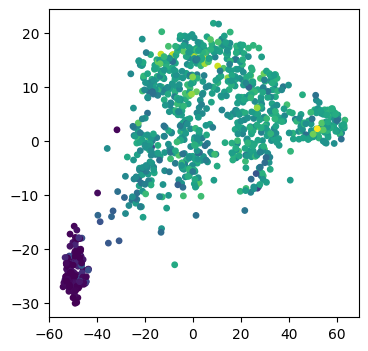

In [13]:
#Fig. 1f
plt.figure(figsize=(4,4))
plt.scatter(
    emb[:, 0],
    emb[:, 1], c=ch_ex_D['YAP1_Expression'], cmap='viridis', vmax=10, vmin=0, s=15)

### Cluster number (Fig. 3a-d)

In [24]:
import pandas as pd
embedding = pd.read_csv("../trimap_hippo.csv",index_col=0).values

Eigenvalues:
lambda_1: 0.000000
lambda_2: 0.000233
lambda_3: 0.004048
lambda_4: 0.008894
lambda_5: 0.014847
lambda_6: 0.030363
lambda_7: 0.039028
lambda_8: 0.043519
lambda_9: 0.056535
lambda_10: 0.068146
lambda_11: 0.081542
lambda_12: 0.088455
lambda_13: 0.105270
lambda_14: 0.129758
lambda_15: 0.140811


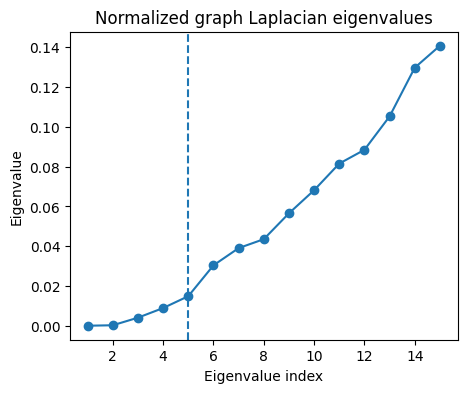

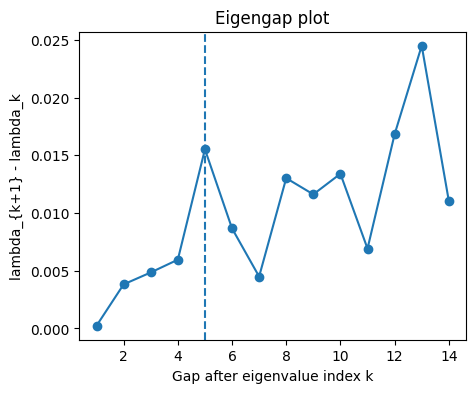

Eigengaps:
gap after k=1: 0.000233
gap after k=2: 0.003815
gap after k=3: 0.004846
gap after k=4: 0.005953
gap after k=5: 0.015516
gap after k=6: 0.008665
gap after k=7: 0.004491
gap after k=8: 0.013015
gap after k=9: 0.011611
gap after k=10: 0.013396
gap after k=11: 0.006913
gap after k=12: 0.016815
gap after k=13: 0.024488
gap after k=14: 0.011053


Text(0.5, 1.0, 'Spectral clustering, k=5')

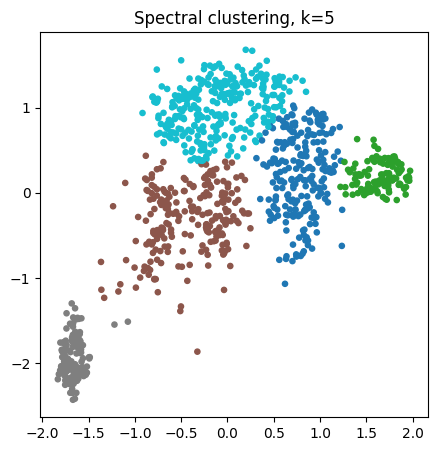

In [28]:
#Fig. S3a-d
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import SpectralClustering
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from scipy.sparse.csgraph import connected_components

X = embedding
# -----------------------------
# 1. Build kNN affinity graph
# -----------------------------
n_neighbors = 30

# distance graph
D = kneighbors_graph(
    X,
    n_neighbors=n_neighbors,
    mode="distance",
    include_self=False
)

# symmetrize distance graph
D = D.maximum(D.T)

# convert distances to RBF-like affinities only on kNN edges
nonzero_dist = D.data
sigma = np.median(nonzero_dist)

A = D.copy()
A.data = np.exp(-(A.data ** 2) / (2 * sigma ** 2))

# check graph connectivity
n_components, component_labels = connected_components(A)

# -----------------------------
# 2. Compute normalized Laplacian eigenvalues
# -----------------------------
L = csgraph.laplacian(A, normed=True)

n_eigs = 15
eigvals, eigvecs = eigsh(L, k=n_eigs, which="SM")
eigvals = np.sort(eigvals)

print("Eigenvalues:")
for i, v in enumerate(eigvals, start=1):
    print(f"lambda_{i}: {v:.6f}")

# plot eigenvalues
plt.figure(figsize=(5, 4))
plt.plot(np.arange(1, n_eigs + 1), eigvals, marker="o")
plt.axvline(5, linestyle="--")
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("Normalized graph Laplacian eigenvalues")
plt.savefig("../result/figure_eigenvalues.svg", dpi=300, bbox_inches="tight")
plt.show()

# plot eigengaps
eigengaps = np.diff(eigvals)

plt.figure(figsize=(5, 4))
plt.plot(np.arange(1, n_eigs), eigengaps, marker="o")
plt.axvline(5, linestyle="--")
plt.xlabel("Gap after eigenvalue index k")
plt.ylabel("lambda_{k+1} - lambda_k")
plt.title("Eigengap plot")
plt.savefig("../result/figure_eigengaps.svg", dpi=300, bbox_inches="tight") 
plt.show()


print("Eigengaps:")
for k, gap in enumerate(eigengaps, start=1):
    print(f"gap after k={k}: {gap:.6f}")


# -----------------------------
# 3. Spectral clustering with k=5
# -----------------------------
k = 5

try:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        assign_labels="cluster_qr",
        random_state=0
    )
    labels = spectral.fit_predict(A)
except ValueError:
    # fallback for older sklearn versions
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        assign_labels="discretize",
        random_state=0
    )
    labels = spectral.fit_predict(A)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, s=14, cmap="tab10")
plt.title("Spectral clustering, k=5")



In [30]:
#Fig. 3f
def make_knn_affinity(X, n_neighbors=30):
    """
    Build symmetric kNN affinity graph with RBF weights.
    """
    n = X.shape[0]
    n_neighbors = min(n_neighbors, n - 1)

    D = kneighbors_graph(
        X,
        n_neighbors=n_neighbors,
        mode="distance",
        include_self=False
    )

    # Symmetrize distance graph
    D = D.maximum(D.T)

    sigma = np.median(D.data)
    if sigma <= 0:
        sigma = np.mean(D.data[D.data > 0])

    A = D.copy()
    A.data = np.exp(-(A.data ** 2) / (2 * sigma ** 2))

    return A


def spectral_cluster_from_affinity(A, k, random_state=0):
    """
    Spectral clustering from precomputed affinity matrix.
    Uses cluster_qr if available, otherwise discretize.
    """
    try:
        model = SpectralClustering(
            n_clusters=k,
            affinity="precomputed",
            assign_labels="cluster_qr",
            random_state=random_state
        )
        labels = model.fit_predict(A)
    except ValueError:
        model = SpectralClustering(
            n_clusters=k,
            affinity="precomputed",
            assign_labels="discretize",
            random_state=random_state
        )
        labels = model.fit_predict(A)

    return labels

def consensus_clustering(
    X,
    k_values=range(2, 11),
    n_runs=100,
    sample_fraction=0.9,
    n_neighbors=30,
    pac_lower=0.1,
    pac_upper=0.9,
    random_state=0
):
    """
    Repeated subsampling consensus clustering.

    Returns:
        consensus_matrices: dict[k] = consensus matrix C
        pac_scores: dict[k] = PAC score
        co_sample_counts: dict[k] = number of times each pair was co-sampled
    """

    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    n_sub = int(np.floor(sample_fraction * n))

    consensus_matrices = {}
    pac_scores = {}
    co_sample_counts = {}

    for k in k_values:
        print(f"Running K={k}")

        same_cluster_count = np.zeros((n, n), dtype=float)
        co_count = np.zeros((n, n), dtype=float)

        for run in range(n_runs):
            idx = rng.choice(n, size=n_sub, replace=False)
            X_sub = X[idx]

            A_sub = make_knn_affinity(X_sub, n_neighbors=n_neighbors)

            n_components, _ = connected_components(A_sub)
            if n_components > 1:
                # Not fatal, but worth knowing
                print(
                    f"  Warning: K={k}, run={run}, graph has "
                    f"{n_components} connected components"
                )

            labels_sub = spectral_cluster_from_affinity(
                A_sub,
                k=k,
                random_state=run
            )

            # Update co-sampled count
            co_count[np.ix_(idx, idx)] += 1

            # Update same-cluster count
            for cluster_id in np.unique(labels_sub):
                members_sub = np.where(labels_sub == cluster_id)[0]
                members_global = idx[members_sub]
                same_cluster_count[np.ix_(members_global, members_global)] += 1

        # Consensus matrix
        C = np.zeros((n, n), dtype=float)
        valid = co_count > 0
        C[valid] = same_cluster_count[valid] / co_count[valid]

        np.fill_diagonal(C, 1.0)

        consensus_matrices[k] = C
        co_sample_counts[k] = co_count

        # PAC score: proportion of ambiguous pairwise consensus values
        upper = np.triu_indices(n, k=1)
        values = C[upper]

        pac = np.mean((values > pac_lower) & (values < pac_upper))
        pac_scores[k] = pac

        print(f"  PAC={pac:.4f}")

    return consensus_matrices, pac_scores, co_sample_counts

consensus_matrices, pac_scores, co_sample_counts = consensus_clustering(
    X,
    k_values=range(2, 11),
    n_runs=100,
    sample_fraction=0.9,
    n_neighbors=30,
    pac_lower=0.1,
    pac_upper=0.9,
    random_state=0
)

Running K=2
  PAC=0.0020
Running K=3
  PAC=0.0339
Running K=4
  PAC=0.0365
Running K=5
  PAC=0.0207
Running K=6
  PAC=0.0727
Running K=7
  PAC=0.0718
Running K=8
  PAC=0.0175
Running K=9
  PAC=0.0154
Running K=10
  PAC=0.0533


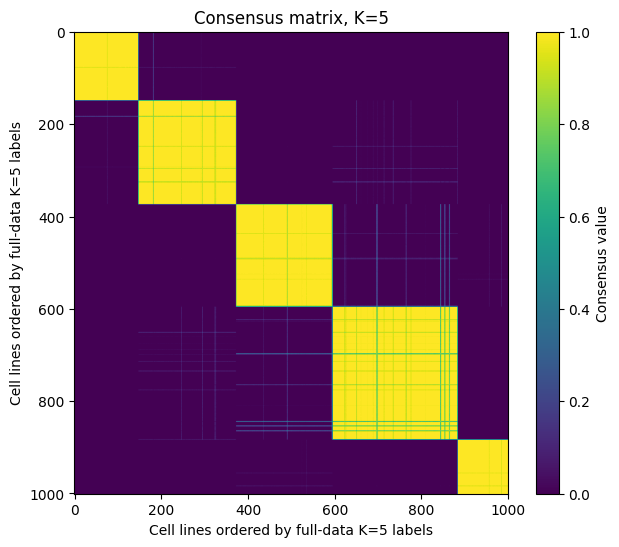

In [31]:
#Fig. S3e
# Full-data K=5 labels
A_full = make_knn_affinity(X, n_neighbors=30)
labels_5 = spectral_cluster_from_affinity(A_full, k=5, random_state=0)

# Order samples by full-data labels
changed = {0:2, 1:4, 2:1,3:0,4:3}
order = np.argsort([changed[label] for label in labels_5])

C5 = consensus_matrices[5]
C5_ordered = C5[np.ix_(order, order)]

plt.figure(figsize=(7, 6))
plt.imshow(C5_ordered, vmin=0, vmax=1, aspect="auto", cmap="viridis")
plt.colorbar(label="Consensus value")
plt.title("Consensus matrix, K=5")
plt.xlabel("Cell lines ordered by full-data K=5 labels")
plt.ylabel("Cell lines ordered by full-data K=5 labels")
plt.savefig("../result/figure_consensus_matrix.svg", dpi=300, bbox_inches="tight")
plt.show()